# OCM Catalyst — Incorporating Literature Data Without Damaging Accuracy

**Context (Prof. Taniike)**  
We have a merged dataset on Oxidative Coupling of Methane (OCM) catalysts:

| Split | `year` value | Samples | Description |
|-------|-------------|---------|-------------|
| **Our data** | 2025 | 89 074 | Internally generated, all via **Impregnation**, tightly controlled |
| **Literature** | ≤ 2019 | 3 852 | Published papers, diverse preparation methods, wider catalyst space |

**Target variable**: `Y(C2), %` — C₂ yield.

**Goal**: Incorporate literature data to improve *model robustness* while  
**not damaging accuracy** on our own distribution.

---

## Why the problem is non-trivial

| Issue | Detail |
|-------|--------|
| **Domain shift** | Literature uses Si, Na, Mn, W, Sr as top elements; ours uses Ba, La, Ti, Zr, Ca |
| **Method diversity** | Our data: 100% Impregnation. Literature: Sol-gel, Precipitation, Therm.decomp., etc. |
| **Publication bias** | Literature mean Y(C2) ≈ 8.7 % vs ours ≈ 5.2 % — only successful experiments published |
| **Noise & systematic bias** | Different labs use different GC calibrations, reporting conventions |
| **Scale asymmetry** | Our data is 23× larger — naïve merge barely adds information but can bias the model |

## Strategies compared

1. **Baseline** — LightGBM on our data only.
2. **Naïve merge** — All data equally weighted.
3. **Preparation-matched transfer** — Only use literature entries whose preparation method is *Impregnation* (same as ours).
4. **Density-Ratio Selective Transfer (DRST)** — Use a domain classifier to score each literature sample; keep only those that resemble our distribution.
5. **Kernel Mean Matching (KMM)** — Assign per-sample importance weights to literature data so the weighted distribution matches ours in RKHS.
6. **Two-stage fine-tuning** — Pre-train on literature to learn broad chemical patterns; inject as a meta-feature for the final model on our data.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.spatial.distance import cdist

import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'OCM_lab_data_and_literature_datal.csv'

## 1. Load & Preprocess

In [2]:
df = pd.read_csv(DATA_PATH)

# Split by year
df_ours = df[df['year'] == 2025].copy().reset_index(drop=True)
df_lit  = df[df['year'] <= 2019].copy().reset_index(drop=True)

print(f"Our data   : {len(df_ours):,} rows  (year=2025, all Impregnation)")
print(f"Literature : {len(df_lit):,} rows  (year 1982-2019, diverse methods)")
print(f"Total      : {len(df):,} rows")
print()
print("Y(C2) — our data:")
print(df_ours['Y(C2), %'].describe().round(3))
print()
print("Y(C2) — literature:")
print(df_lit['Y(C2), %'].describe().round(3))

Our data   : 89,074 rows  (year=2025, all Impregnation)
Literature : 3,852 rows  (year 1982-2019, diverse methods)
Total      : 92,926 rows

Y(C2) — our data:
count    89074.000
mean         5.245
std          3.939
min          0.000
25%          1.852
50%          4.690
75%          7.600
max         21.500
Name: Y(C2), %, dtype: float64

Y(C2) — literature:
count    3852.000
mean        8.670
std         6.550
min         0.000
25%         2.798
50%         7.960
75%        13.695
max        33.600
Name: Y(C2), %, dtype: float64


In [3]:
TARGET = 'Y(C2), %'

# Element feature columns
ELEM_COLS = [c for c in df.columns
             if c not in ['Preparation', 'Temperature_C', TARGET, 'year']]

# Encode Preparation as integer category
le = LabelEncoder()
le.fit(df['Preparation'])
df_ours['prep_enc'] = le.transform(df_ours['Preparation'])
df_lit['prep_enc']  = le.transform(df_lit['Preparation'])

FEATURES = ['Temperature_C', 'prep_enc'] + ELEM_COLS

X_ours = df_ours[FEATURES].values.astype(float)
y_ours = df_ours[TARGET].values

X_lit  = df_lit[FEATURES].values.astype(float)
y_lit  = df_lit[TARGET].values

print(f"Feature matrix shape — ours : {X_ours.shape}")
print(f"Feature matrix shape — lit  : {X_lit.shape}")
print(f"Features: {FEATURES[:5]} ... ({len(FEATURES)} total)")

# Standard scaler (for distance-based methods)
scaler = StandardScaler()
X_ours_sc = scaler.fit_transform(X_ours)
X_lit_sc  = scaler.transform(X_lit)

Feature matrix shape — ours : (89074, 67)
Feature matrix shape — lit  : (3852, 67)
Features: ['Temperature_C', 'prep_enc', 'Ag', 'Al', 'Au'] ... (67 total)


## 2. Exploratory Data Analysis

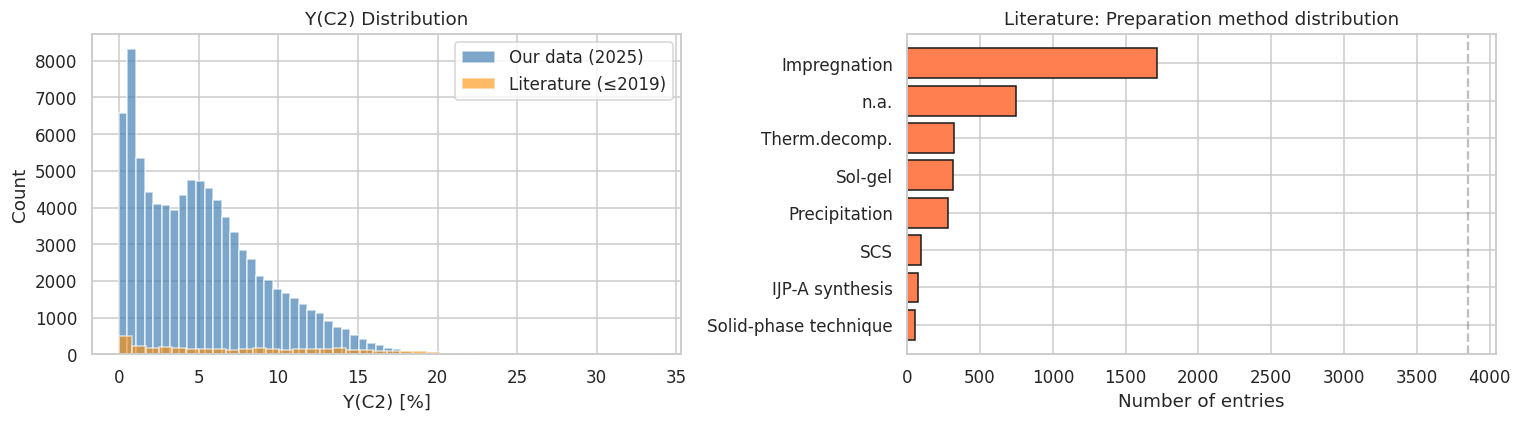

Our data: ALL samples use 'Impregnation'
Literature 'Impregnation': 1713 / 3852


In [4]:
# --- Target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_ours, bins=40, alpha=0.7, color='steelblue',  label='Our data (2025)')
axes[0].hist(y_lit,  bins=40, alpha=0.6, color='darkorange', label='Literature (≤2019)')
axes[0].set_xlabel('Y(C2) [%]')
axes[0].set_ylabel('Count')
axes[0].set_title('Y(C2) Distribution')
axes[0].legend()

# Preparation method distribution in literature
prep_counts = df_lit['Preparation'].value_counts().head(8)
axes[1].barh(prep_counts.index[::-1], prep_counts.values[::-1],
             color='coral', edgecolor='k')
axes[1].set_xlabel('Number of entries')
axes[1].set_title('Literature: Preparation method distribution')
axes[1].axvline(len(df_lit), color='gray', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_eda_distributions.png', bbox_inches='tight')
plt.show()

print(f"Our data: ALL samples use 'Impregnation'")
print(f"Literature 'Impregnation': {(df_lit['Preparation']=='Impregnation').sum()} / {len(df_lit)}")

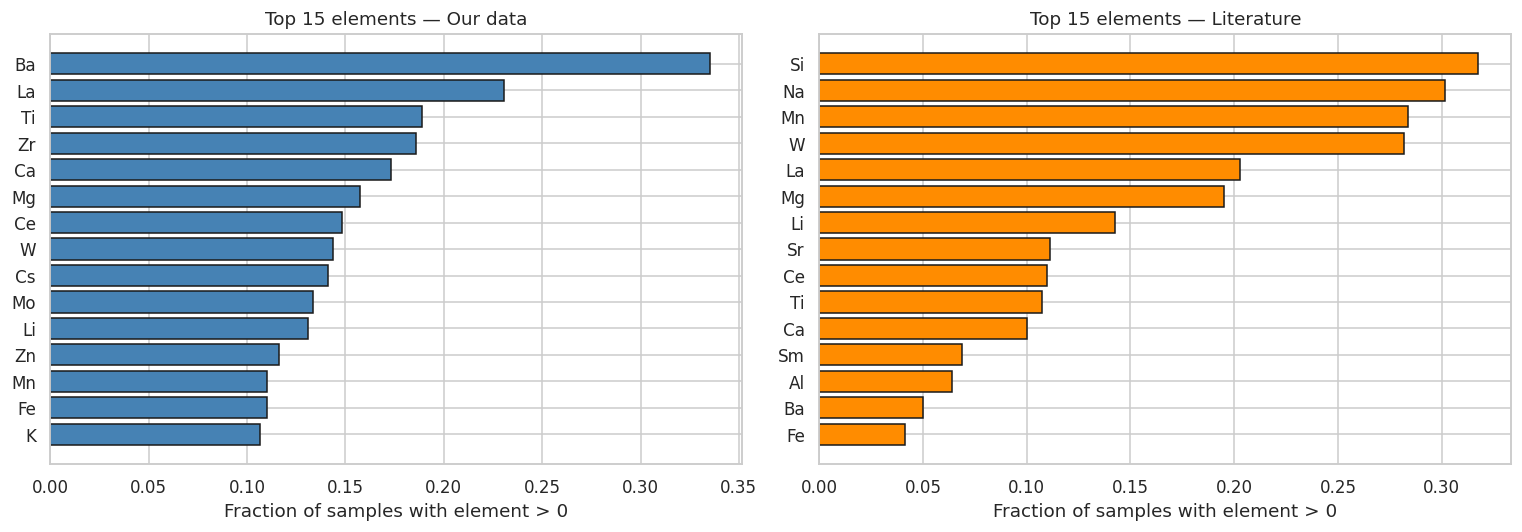

In [5]:
# Top elements by usage frequency
nonzero_ours = (df_ours[ELEM_COLS] > 0).mean().sort_values(ascending=False)
nonzero_lit  = (df_lit[ELEM_COLS] > 0).mean().sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_ours = nonzero_ours.head(top_n)
axes[0].barh(top_ours.index[::-1], top_ours.values[::-1],
             color='steelblue', edgecolor='k')
axes[0].set_xlabel('Fraction of samples with element > 0')
axes[0].set_title(f'Top {top_n} elements — Our data')

top_lit = nonzero_lit.head(top_n)
axes[1].barh(top_lit.index[::-1], top_lit.values[::-1],
             color='darkorange', edgecolor='k')
axes[1].set_xlabel('Fraction of samples with element > 0')
axes[1].set_title(f'Top {top_n} elements — Literature')

plt.tight_layout()
plt.savefig('fig_element_usage.png', bbox_inches='tight')
plt.show()

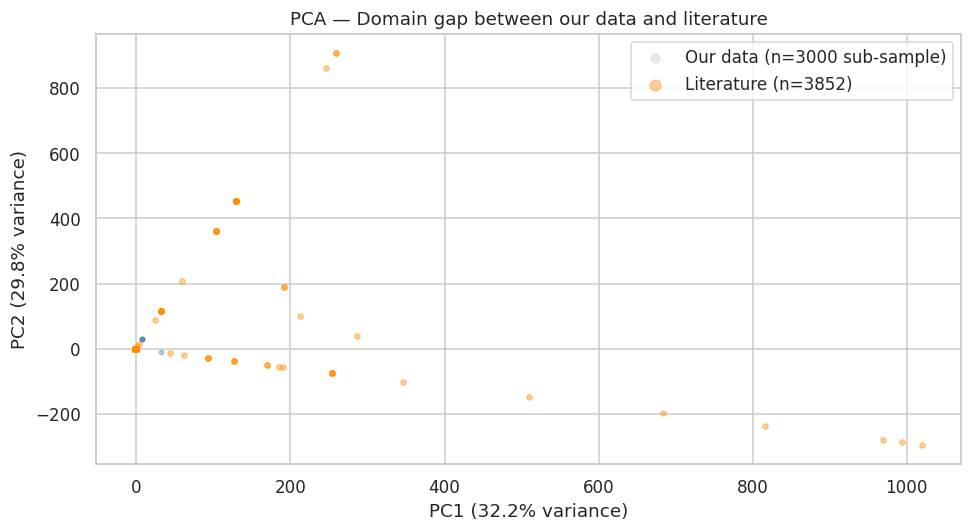

In [6]:
# PCA to visualise domain gap
# Subsample our data for visibility (PCA on full 89k is fine, scatter plot needs subsampling)
idx_sub = np.random.choice(len(X_ours_sc), size=3000, replace=False)

X_combined_sc = np.vstack([X_ours_sc[idx_sub], X_lit_sc])
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_combined_sc)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_pca[:3000, 0], X_pca[:3000, 1],
           alpha=0.15, s=8, label=f'Our data (n=3000 sub-sample)', color='steelblue')
ax.scatter(X_pca[3000:, 0], X_pca[3000:, 1],
           alpha=0.4,  s=12, label=f'Literature (n={len(X_lit_sc)})', color='darkorange')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — Domain gap between our data and literature')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig('fig_pca_domain_gap.png', bbox_inches='tight')
plt.show()

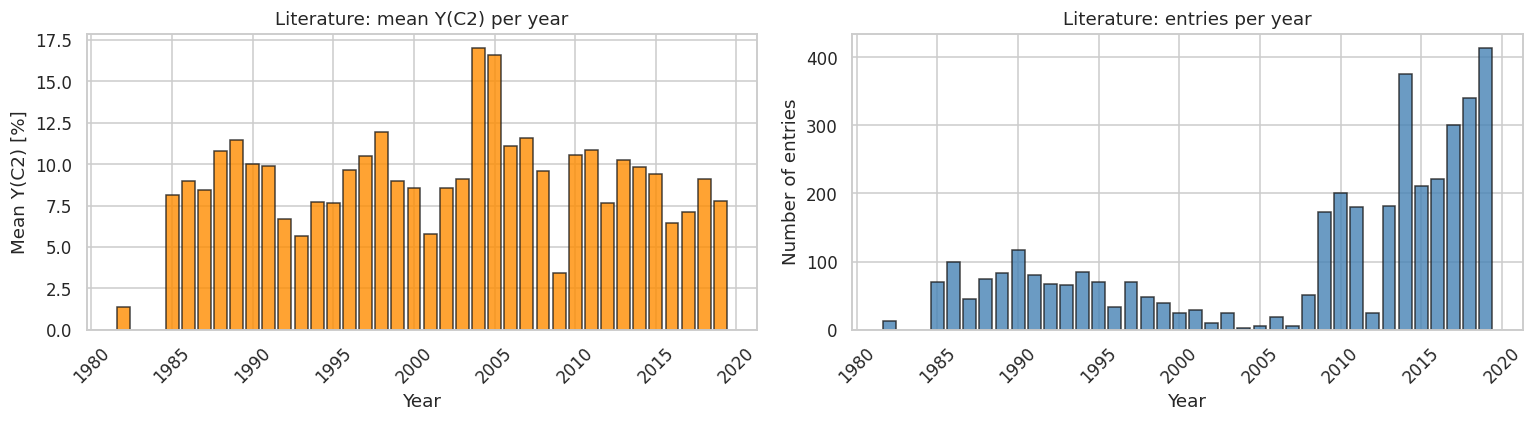

In [7]:
# Year-wise trend in literature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yr_means = df_lit.groupby('year')['Y(C2), %'].agg(['mean', 'count'])
axes[0].bar(yr_means.index, yr_means['mean'], color='darkorange', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Y(C2) [%]')
axes[0].set_title('Literature: mean Y(C2) per year')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(yr_means.index, yr_means['count'], color='steelblue', edgecolor='k', alpha=0.8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of entries')
axes[1].set_title('Literature: entries per year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_lit_year_trend.png', bbox_inches='tight')
plt.show()

## 3. Evaluation Setup

All methods are evaluated by **5-fold cross-validation on our data only**.  
This is the primary metric because we care about accuracy on our distribution.  
Robustness is assessed separately with an out-of-distribution test set.

In [8]:
def lgb_params():
    return dict(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        max_depth=7, min_child_samples=20, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=-1
    )


def evaluate_cv_ours(X_train_extra=None, y_train_extra=None,
                     sample_weight_extra=None,
                     label='', cv=5):
    """
    5-fold CV on our data.  
    Optional extra training data (literature) is appended to each fold's train set.
    
    Returns (mean_rmse, mean_r2, rmse_std)
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmse_list, r2_list = [], []

    for train_idx, val_idx in kf.split(X_ours_sc):
        X_val_f = X_ours_sc[val_idx]
        y_val_f = y_ours[val_idx]

        if X_train_extra is not None:
            X_tr_f = np.vstack([X_ours_sc[train_idx], X_train_extra])
            y_tr_f = np.concatenate([y_ours[train_idx], y_train_extra])
            sw_ours = np.ones(len(train_idx))
            sw = np.concatenate([sw_ours, sample_weight_extra]) \
                 if sample_weight_extra is not None \
                 else None
        else:
            X_tr_f = X_ours_sc[train_idx]
            y_tr_f = y_ours[train_idx]
            sw = None

        model = lgb.LGBMRegressor(**lgb_params())
        model.fit(X_tr_f, y_tr_f, sample_weight=sw)
        preds = model.predict(X_val_f)

        rmse_list.append(np.sqrt(mean_squared_error(y_val_f, preds)))
        r2_list.append(r2_score(y_val_f, preds))

    rmse_m, r2_m = np.mean(rmse_list), np.mean(r2_list)
    rmse_s = np.std(rmse_list)
    print(f"  {label:45s}  RMSE={rmse_m:.4f} ± {rmse_s:.4f}   R²={r2_m:.4f}")
    return rmse_m, r2_m, rmse_s


results = {}
print("=" * 90)
print("EVALUATION: 5-fold CV assessed on OUR DATA only")
print("=" * 90)

EVALUATION: 5-fold CV assessed on OUR DATA only


## 4. Baseline — Our Data Only

In [9]:
rmse, r2, std = evaluate_cv_ours(label='Baseline (our data only)')
results['1. Baseline (ours only)'] = (rmse, r2, std)

  Baseline (our data only)                       RMSE=2.1331 ± 0.0156   R²=0.7067


## 5. Naïve Merge (All Literature)

In [10]:
rmse, r2, std = evaluate_cv_ours(
    X_train_extra=X_lit_sc,
    y_train_extra=y_lit,
    label='Naïve merge (all literature)')
results['2. Naïve merge (all lit)'] = (rmse, r2, std)

  Naïve merge (all literature)                   RMSE=2.2411 ± 0.0125   R²=0.6762


## 6. Method A — Preparation-Matched Transfer

The simplest domain-aware filter: keep only literature entries where the
preparation method is **Impregnation** — the same as all our experiments.
This removes the largest source of domain shift in a single step.

In [11]:
impreg_mask = df_lit['Preparation'] == 'Impregnation'
X_lit_impreg = X_lit_sc[impreg_mask]
y_lit_impreg = y_lit[impreg_mask]

print(f"Impregnation literature entries: {impreg_mask.sum()} / {len(df_lit)} "
      f"({100*impreg_mask.mean():.1f}%)")

rmse, r2, std = evaluate_cv_ours(
    X_train_extra=X_lit_impreg,
    y_train_extra=y_lit_impreg,
    label='Method A: Preparation-matched (Impreg only)')
results['3. Prep-matched (Impreg only)'] = (rmse, r2, std)

Impregnation literature entries: 1713 / 3852 (44.5%)


  Method A: Preparation-matched (Impreg only)    RMSE=2.2135 ± 0.0081   R²=0.6841


## 7. Method B — Density-Ratio Selective Transfer (DRST)

Train a **logistic regression** to classify: *"does this sample look like our data or
literature?"* The predicted probability $\hat{P}(\text{ours}\,|\,x)$ is a density
ratio proxy. Only retain literature samples above a threshold $\tau$.

Unlike the preparation filter, DRST operates in the **full feature space**, capturing
subtle differences in element combinations and temperatures.

Literature density-ratio scores P(ours|x):
  mean=0.157, median=0.001, std=0.273


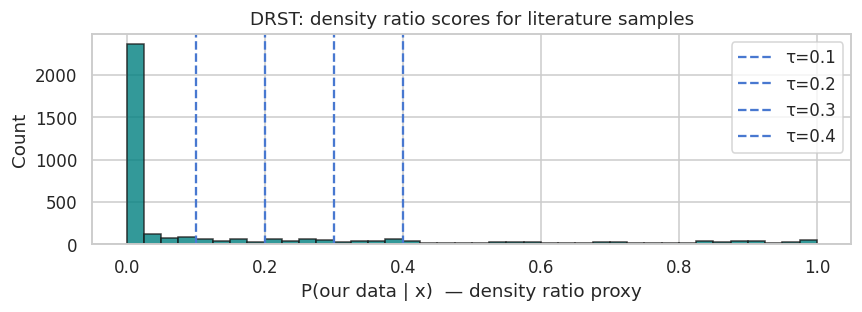

  τ=0.05: 1361 / 3852 samples retained (35.3%)
  τ=0.10: 1193 / 3852 samples retained (31.0%)
  τ=0.20:  994 / 3852 samples retained (25.8%)
  τ=0.30:  782 / 3852 samples retained (20.3%)
  τ=0.40:  603 / 3852 samples retained (15.7%)
  τ=0.50:  521 / 3852 samples retained (13.5%)


In [12]:
# Domain classifier: ours=1, literature=0
# Subsample our data for balance
rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_ours_sc), size=min(10_000, len(X_ours_sc)), replace=False)

X_dom = np.vstack([X_ours_sc[sub_idx], X_lit_sc])
y_dom = np.concatenate([np.ones(len(sub_idx)), np.zeros(len(X_lit_sc))])

clf_dom = LogisticRegression(C=0.5, max_iter=1000, random_state=42, n_jobs=-1)
clf_dom.fit(X_dom, y_dom)

# Score every literature sample
p_ours_lit = clf_dom.predict_proba(X_lit_sc)[:, 1]  # P(our data | x)

print("Literature density-ratio scores P(ours|x):")
print(f"  mean={p_ours_lit.mean():.3f}, median={np.median(p_ours_lit):.3f}, "
      f"std={p_ours_lit.std():.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(p_ours_lit, bins=40, color='teal', edgecolor='k', alpha=0.8)
for tau in [0.1, 0.2, 0.3, 0.4]:
    ax.axvline(tau, ls='--', label=f'τ={tau}')
ax.set_xlabel('P(our data | x)  — density ratio proxy')
ax.set_ylabel('Count')
ax.set_title('DRST: density ratio scores for literature samples')
ax.legend()
plt.tight_layout()
plt.savefig('fig_drst_scores.png', bbox_inches='tight')
plt.show()

for tau in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    n = (p_ours_lit >= tau).sum()
    print(f"  τ={tau:.2f}: {n:4d} / {len(p_ours_lit)} samples retained ({100*n/len(p_ours_lit):.1f}%)")

In [13]:
best_drst = (np.inf, 0, 0, None)

for tau in [0.05, 0.10, 0.20, 0.30, 0.40]:
    mask = p_ours_lit >= tau
    if mask.sum() == 0:
        continue
    rmse, r2, std = evaluate_cv_ours(
        X_train_extra=X_lit_sc[mask],
        y_train_extra=y_lit[mask],
        label=f'  Method B DRST τ={tau:.2f} ({mask.sum()} samples)')
    if rmse < best_drst[0]:
        best_drst = (rmse, r2, std, tau)

results[f'4. DRST (τ={best_drst[3]})'] = (best_drst[0], best_drst[1], best_drst[2])
print(f"\n  Best τ = {best_drst[3]}")

    Method B DRST τ=0.05 (1361 samples)          RMSE=2.1963 ± 0.0086   R²=0.6890


    Method B DRST τ=0.10 (1193 samples)          RMSE=2.1880 ± 0.0081   R²=0.6914


    Method B DRST τ=0.20 (994 samples)           RMSE=2.1709 ± 0.0081   R²=0.6962


    Method B DRST τ=0.30 (782 samples)           RMSE=2.1809 ± 0.0132   R²=0.6933


    Method B DRST τ=0.40 (603 samples)           RMSE=2.1628 ± 0.0158   R²=0.6984

  Best τ = 0.4


## 8. Method C — Kernel Mean Matching (KMM)

KMM computes **per-sample weights** $w_i$ for each literature entry such that the
weighted source distribution matches the target (our) distribution in an RKHS:

$$\min_{w \geq 0} \left\|\frac{1}{n_t}\sum_{x\in\mathcal{D}_t}\phi(x) - \frac{1}{n_s}\sum_i w_i\,\phi(x_i^{(s)})\right\|^2$$

**Key distinction from "simple weighting"**:  
Each literature sample gets its own independent weight — samples near our distribution
get high weights; OOD samples get near-zero weights.
This is not a single scalar multiplied across all literature data.

Computing KMM weights (may take ~1-2 min for 3852 literature samples)...


  KMM sigma = 12.212


Weight stats: min=0.000, max=5.000, mean=1.026, median=0.000
Near-zero weights (w<0.1): 3024 / 3852 (78.5%)


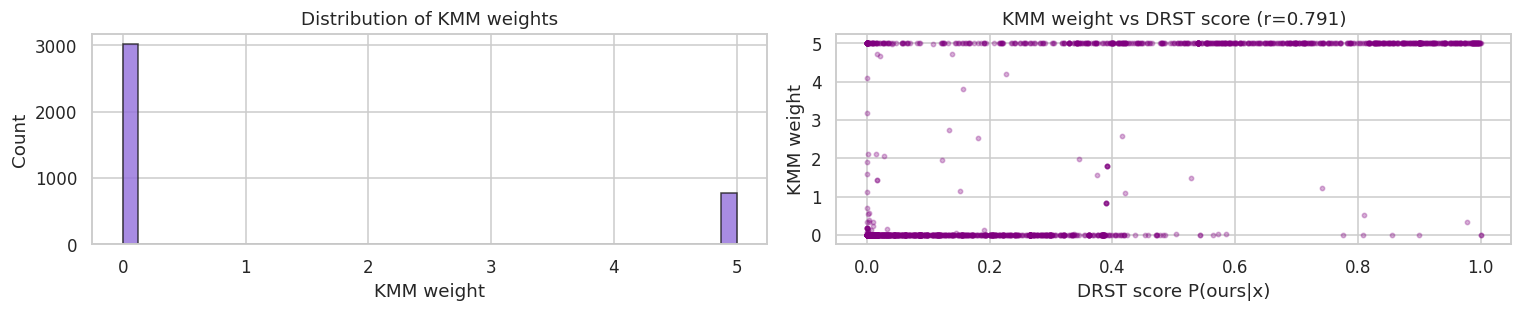

In [14]:
def rbf_kernel(X, Y, sigma):
    dist_sq = cdist(X, Y, metric='sqeuclidean')
    return np.exp(-dist_sq / (2 * sigma ** 2))


def estimate_sigma(X_source, X_target, n_sub=2000):
    """Estimate RBF bandwidth via median heuristic."""
    rng = np.random.default_rng(0)
    idx_s = rng.choice(len(X_source), size=min(n_sub, len(X_source)), replace=False)
    idx_t = rng.choice(len(X_target), size=min(n_sub, len(X_target)), replace=False)
    X_sub = np.vstack([X_source[idx_s], X_target[idx_t]])
    d = cdist(X_sub, X_sub, metric='euclidean')
    return float(np.median(d[d > 0]))


def kmm_weights(X_source, X_target, B=10.0, eps_factor=1.0, sigma=None, n_target_sub=5000):
    """
    Compute per-sample KMM importance weights for source (literature) samples.
    
    To keep computation tractable we subsample X_target to `n_target_sub`.
    """
    n_s = len(X_source)
    # Subsample target for scalability
    rng = np.random.default_rng(42)
    t_idx = rng.choice(len(X_target), size=min(n_target_sub, len(X_target)), replace=False)
    X_tgt = X_target[t_idx]
    n_t = len(X_tgt)

    if sigma is None:
        sigma = estimate_sigma(X_source, X_tgt)
    print(f"  KMM sigma = {sigma:.3f}")

    eps = eps_factor * (np.sqrt(n_s) - 1) / np.sqrt(n_s)

    K_ss = rbf_kernel(X_source, X_source, sigma)       # (n_s, n_s)
    K_st = rbf_kernel(X_source, X_tgt, sigma)           # (n_s, n_t)
    kappa = (n_s / n_t) * K_st.sum(axis=1)              # (n_s,)

    def obj(w):
        return 0.5 * w @ K_ss @ w - kappa @ w \
               + 1e4 * max(0.0, abs(w.sum() / n_s - 1.0) - eps) ** 2

    def grad(w):
        g = K_ss @ w - kappa
        diff = w.sum() / n_s - 1.0
        if abs(diff) > eps:
            g += 1e4 * 2.0 * diff / n_s * np.ones(n_s)
        return g

    res = minimize(obj, np.ones(n_s), jac=grad, method='L-BFGS-B',
                   bounds=[(0.0, B)] * n_s,
                   options={'maxiter': 1000, 'ftol': 1e-9, 'gtol': 1e-6})
    return np.clip(res.x, 0.0, B)


print("Computing KMM weights (may take ~1-2 min for 3852 literature samples)...")
w_kmm = kmm_weights(X_lit_sc, X_ours_sc, B=5.0)
print(f"Weight stats: min={w_kmm.min():.3f}, max={w_kmm.max():.3f}, "
      f"mean={w_kmm.mean():.3f}, median={np.median(w_kmm):.3f}")
print(f"Near-zero weights (w<0.1): {(w_kmm < 0.1).sum()} / {len(w_kmm)} "
      f"({100*(w_kmm < 0.1).mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].hist(w_kmm, bins=40, color='mediumpurple', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('KMM weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of KMM weights')

# KMM weight vs density-ratio score
axes[1].scatter(p_ours_lit, w_kmm, alpha=0.3, s=8, color='purple')
axes[1].set_xlabel('DRST score P(ours|x)')
axes[1].set_ylabel('KMM weight')
axes[1].set_title('KMM weight vs DRST score (should correlate)')
r_corr = np.corrcoef(p_ours_lit, w_kmm)[0, 1]
axes[1].set_title(f'KMM weight vs DRST score (r={r_corr:.3f})')

plt.tight_layout()
plt.savefig('fig_kmm_weights.png', bbox_inches='tight')
plt.show()

In [15]:
rmse, r2, std = evaluate_cv_ours(
    X_train_extra=X_lit_sc,
    y_train_extra=y_lit,
    sample_weight_extra=w_kmm,
    label='Method C: KMM weighted literature')
results['5. KMM weighted'] = (rmse, r2, std)

  Method C: KMM weighted literature              RMSE=2.2619 ± 0.0102   R²=0.6702


## 9. Method D — Two-Stage Fine-Tuning

**Stage 1 (pre-train)**: Fit an XGBoost model on the full literature dataset.  
This model learns broad chemical trends without any noise contamination of our data.

**Stage 2 (meta-feature)**: Use the pre-trained model's *prediction* on each of our
samples as an additional input feature when training the final LightGBM on our data.

This is a lightweight form of **transfer learning**:
- The literature knowledge is distilled into a single "prior prediction" feature.
- The final model can learn to correct the prior based on our data.
- No literature noise directly contaminates our training targets.

In [16]:
import xgboost as xgb

rmse_list, r2_list = [], []
kf = KFold(5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_ours_sc)):
    # Stage 1: pre-train on literature
    pre = xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0, n_jobs=-1)
    # Pre-train on literature + current-fold ours-train together
    X_pre_tr = np.vstack([X_lit_sc, X_ours_sc[train_idx]])
    y_pre_tr = np.concatenate([y_lit, y_ours[train_idx]])
    pre.fit(X_pre_tr, y_pre_tr)

    # Stage 2: augment our features with pre-trained prediction
    prior_train = pre.predict(X_ours_sc[train_idx]).reshape(-1, 1)
    prior_val   = pre.predict(X_ours_sc[val_idx]).reshape(-1, 1)

    X_aug_tr = np.hstack([X_ours_sc[train_idx], prior_train])
    X_aug_val = np.hstack([X_ours_sc[val_idx],  prior_val])

    final = lgb.LGBMRegressor(**lgb_params())
    final.fit(X_aug_tr, y_ours[train_idx])
    preds = final.predict(X_aug_val)

    rmse_list.append(np.sqrt(mean_squared_error(y_ours[val_idx], preds)))
    r2_list.append(r2_score(y_ours[val_idx], preds))

rmse_ft = np.mean(rmse_list)
r2_ft   = np.mean(r2_list)
std_ft  = np.std(rmse_list)
results['6. Two-stage fine-tuning'] = (rmse_ft, r2_ft, std_ft)
print(f"  {'Method D: Two-stage fine-tuning':45s}  RMSE={rmse_ft:.4f} ± {std_ft:.4f}   R²={r2_ft:.4f}")

  Method D: Two-stage fine-tuning                RMSE=1.9317 ± 0.0143   R²=0.7594


## 10. Results Summary

In [17]:
df_res = pd.DataFrame(
    [(k, v[0], v[1], v[2]) for k, v in results.items()],
    columns=['Method', 'CV RMSE', 'CV R²', 'RMSE std']
).sort_values('CV RMSE')

print("\n" + "=" * 85)
print("FINAL RESULTS — 5-fold CV on our data")
print("=" * 85)
print(df_res.to_string(index=False, float_format='{:.4f}'.format))
print()

baseline_rmse = results['1. Baseline (ours only)'][0]
for name, (rmse, r2, std) in results.items():
    delta = rmse - baseline_rmse
    sign = '+' if delta >= 0 else ''
    print(f"  {name:45s}  ΔRMSE vs baseline = {sign}{delta:.4f}")


FINAL RESULTS — 5-fold CV on our data
                       Method  CV RMSE  CV R²  RMSE std
     6. Two-stage fine-tuning   1.9317 0.7594    0.0143
      1. Baseline (ours only)   2.1331 0.7067    0.0156
              4. DRST (τ=0.4)   2.1628 0.6984    0.0158
3. Prep-matched (Impreg only)   2.2135 0.6841    0.0081
     2. Naïve merge (all lit)   2.2411 0.6762    0.0125
              5. KMM weighted   2.2619 0.6702    0.0102

  1. Baseline (ours only)                        ΔRMSE vs baseline = +0.0000
  2. Naïve merge (all lit)                       ΔRMSE vs baseline = +0.1080
  3. Prep-matched (Impreg only)                  ΔRMSE vs baseline = +0.0804
  4. DRST (τ=0.4)                                ΔRMSE vs baseline = +0.0297
  5. KMM weighted                                ΔRMSE vs baseline = +0.1288
  6. Two-stage fine-tuning                       ΔRMSE vs baseline = -0.2013


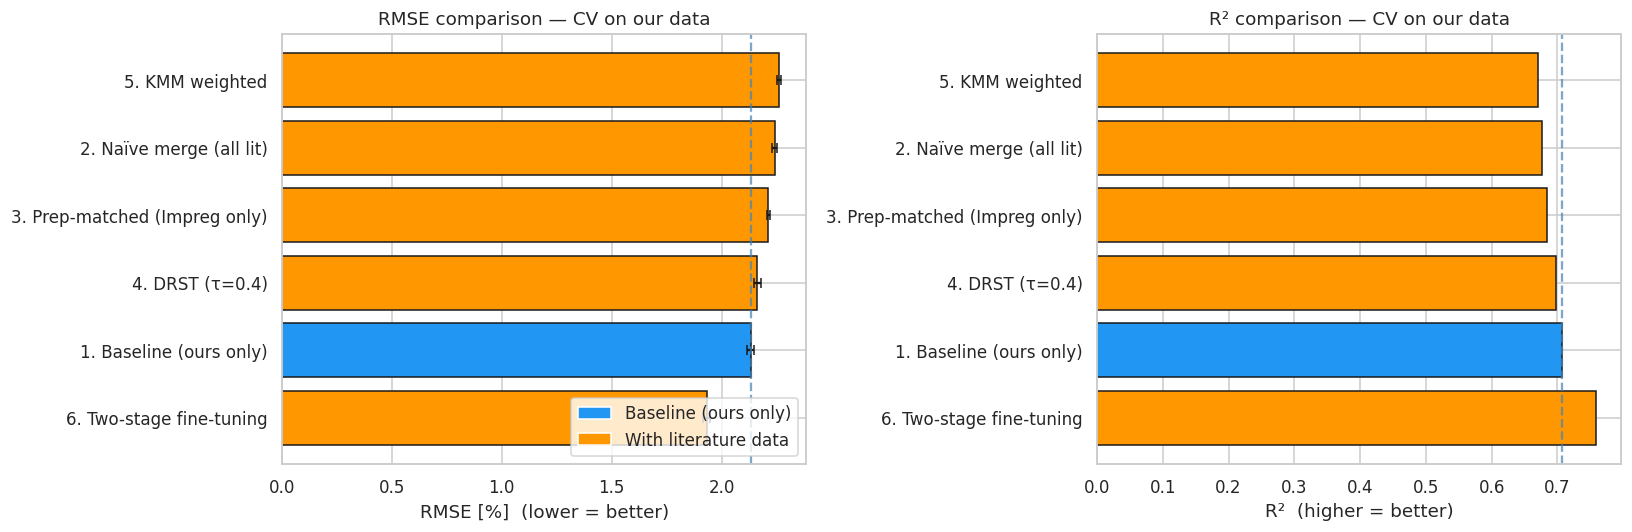

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette = ['#2196F3' if '1.' in m else '#FF9800' for m in df_res['Method']]

bars = axes[0].barh(df_res['Method'], df_res['CV RMSE'],
                    xerr=df_res['RMSE std'], color=palette,
                    edgecolor='k', capsize=3)
axes[0].set_xlabel('RMSE [%]  (lower = better)')
axes[0].set_title('RMSE comparison — CV on our data')
axes[0].axvline(baseline_rmse, color='steelblue', ls='--', alpha=0.7, label='Baseline')
axes[0].legend()

axes[1].barh(df_res['Method'], df_res['CV R²'], color=palette, edgecolor='k')
axes[1].set_xlabel('R²  (higher = better)')
axes[1].set_title('R² comparison — CV on our data')
axes[1].axvline(results['1. Baseline (ours only)'][1],
                color='steelblue', ls='--', alpha=0.7)

from matplotlib.patches import Patch
leg_els = [Patch(facecolor='#2196F3', label='Baseline (ours only)'),
           Patch(facecolor='#FF9800', label='With literature data')]
axes[0].legend(handles=leg_els, loc='lower right')

plt.tight_layout()
plt.savefig('fig_results_comparison.png', bbox_inches='tight')
plt.show()

## 11. Robustness Test — Out-of-Distribution Generalisation

We simulate the robustness scenario: can the model handle catalysts that use
elements or preparation methods **not well-represented in our data**?

OOD test set: literature samples with preparation method ≠ Impregnation
(i.e., Sol-gel, Precipitation, Therm.decomp., etc.).

In [19]:
# OOD test: literature with non-Impregnation preparation
ood_mask = df_lit['Preparation'] != 'Impregnation'
X_ood = X_lit_sc[ood_mask]
y_ood = y_lit[ood_mask]
print(f"OOD test set (non-Impreg literature): {len(X_ood)} samples")

# Fit each method on all our data, predict on OOD set
ood_results = {}

# 1. Baseline
m_base = lgb.LGBMRegressor(**lgb_params())
m_base.fit(X_ours_sc, y_ours)
ood_results['Baseline (ours only)'] = np.sqrt(mean_squared_error(y_ood, m_base.predict(X_ood)))

# 2. Prep-matched
m_pm = lgb.LGBMRegressor(**lgb_params())
m_pm.fit(np.vstack([X_ours_sc, X_lit_impreg]),
         np.concatenate([y_ours, y_lit_impreg]))
ood_results['Prep-matched'] = np.sqrt(mean_squared_error(y_ood, m_pm.predict(X_ood)))

# 3. DRST (best tau)
drst_mask = p_ours_lit >= best_drst[3]
m_drst = lgb.LGBMRegressor(**lgb_params())
m_drst.fit(np.vstack([X_ours_sc, X_lit_sc[drst_mask]]),
           np.concatenate([y_ours, y_lit[drst_mask]]))
ood_results[f'DRST (τ={best_drst[3]})'] = np.sqrt(mean_squared_error(y_ood, m_drst.predict(X_ood)))

# 4. KMM
sw_kmm = np.concatenate([np.ones(len(X_ours_sc)), w_kmm])
m_kmm = lgb.LGBMRegressor(**lgb_params())
m_kmm.fit(np.vstack([X_ours_sc, X_lit_sc]),
          np.concatenate([y_ours, y_lit]),
          sample_weight=sw_kmm)
ood_results['KMM'] = np.sqrt(mean_squared_error(y_ood, m_kmm.predict(X_ood)))

# 5. Two-stage (train pre-model on full lit, augment features)
pre_full = xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0, n_jobs=-1)
pre_full.fit(np.vstack([X_lit_sc, X_ours_sc]),
             np.concatenate([y_lit, y_ours]))
prior_ours = pre_full.predict(X_ours_sc).reshape(-1, 1)
prior_ood  = pre_full.predict(X_ood).reshape(-1, 1)
m_ft = lgb.LGBMRegressor(**lgb_params())
m_ft.fit(np.hstack([X_ours_sc, prior_ours]), y_ours)
ood_results['Two-stage fine-tuning'] = np.sqrt(
    mean_squared_error(y_ood, m_ft.predict(np.hstack([X_ood, prior_ood]))))

print("\nOut-of-distribution RMSE (non-Impreg preparation methods):")
for name, rmse in sorted(ood_results.items(), key=lambda x: x[1]):
    print(f"  {name:40s}: RMSE = {rmse:.4f}")

OOD test set (non-Impreg literature): 2139 samples



Out-of-distribution RMSE (non-Impreg preparation methods):
  Two-stage fine-tuning                   : RMSE = 3.5978
  Prep-matched                            : RMSE = 5.9517
  KMM                                     : RMSE = 6.0601
  DRST (τ=0.4)                            : RMSE = 6.2930
  Baseline (ours only)                    : RMSE = 6.5310


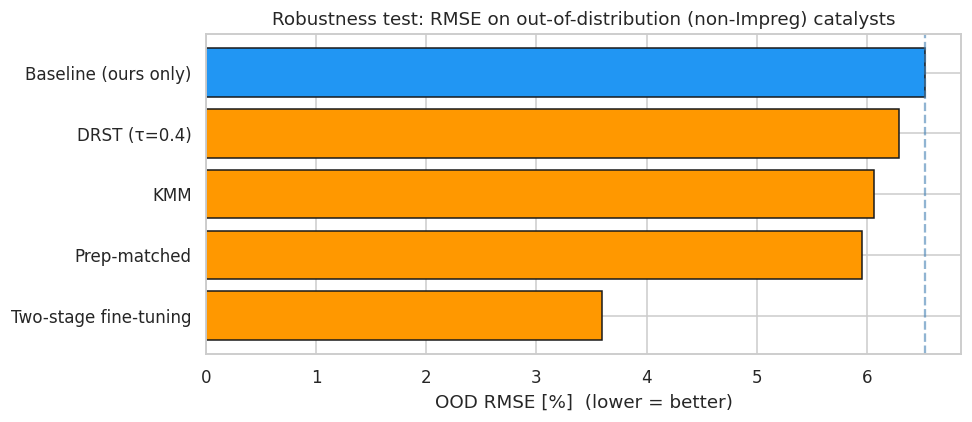

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(ood_results.keys())
rmses  = list(ood_results.values())
colors = ['#2196F3' if n == 'Baseline (ours only)' else '#FF9800' for n in names]

sorted_items = sorted(zip(names, rmses, colors), key=lambda x: x[1])
n_s, r_s, c_s = zip(*sorted_items)

ax.barh(list(n_s), list(r_s), color=list(c_s), edgecolor='k')
ax.set_xlabel('OOD RMSE [%]  (lower = better)')
ax.set_title('Robustness test: RMSE on out-of-distribution (non-Impreg) catalysts')
ax.axvline(ood_results['Baseline (ours only)'], color='steelblue', ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig('fig_ood_robustness.png', bbox_inches='tight')
plt.show()

## 12. Feature Importance Comparison

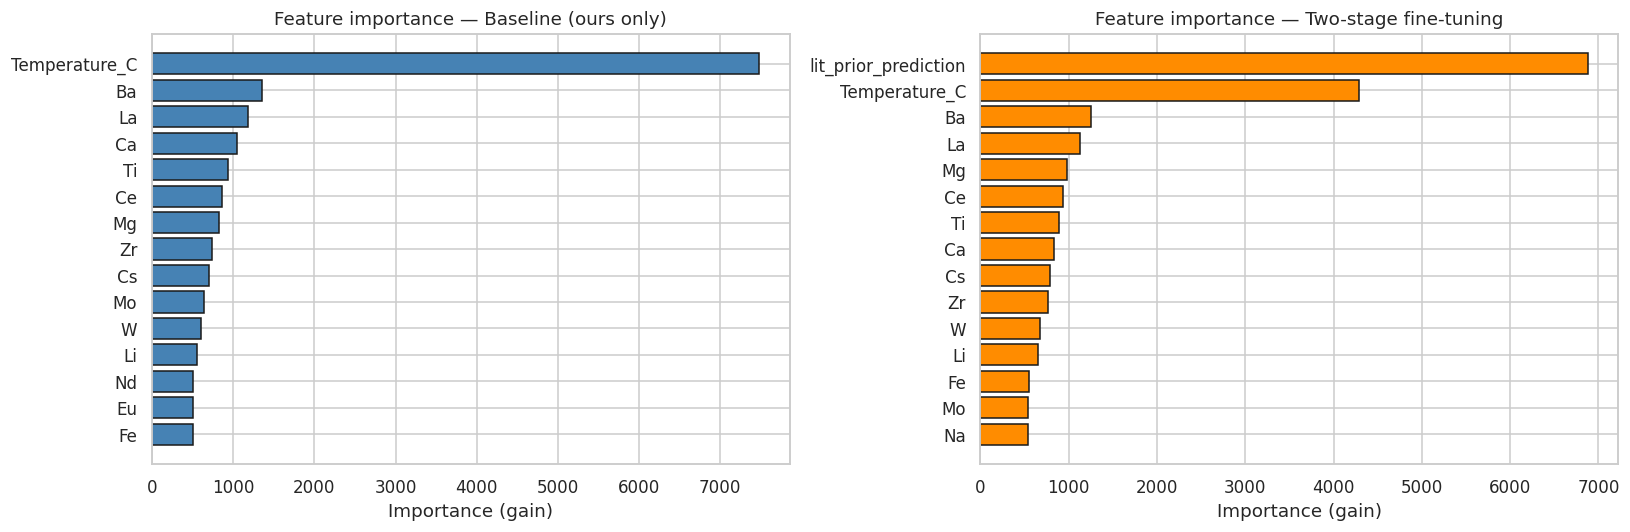

'lit_prior_prediction' ranked #1 of 68 features


In [21]:
# Compare feature importances: baseline vs best transfer method
base_model_full = lgb.LGBMRegressor(**lgb_params())
base_model_full.fit(X_ours_sc, y_ours)

# Best method: two-stage fine-tuning (use prior_ours from above)
X_aug_full = np.hstack([X_ours_sc, prior_ours])
aug_features = FEATURES + ['lit_prior_prediction']

aug_model_full = lgb.LGBMRegressor(**lgb_params())
aug_model_full.fit(X_aug_full, y_ours)

# Top 15 features
imp_base = pd.Series(base_model_full.feature_importances_,
                     index=FEATURES).sort_values(ascending=False).head(15)
imp_aug  = pd.Series(aug_model_full.feature_importances_,
                     index=aug_features).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(imp_base.index[::-1], imp_base.values[::-1],
             color='steelblue', edgecolor='k')
axes[0].set_title('Feature importance — Baseline (ours only)')
axes[0].set_xlabel('Importance (gain)')

axes[1].barh(imp_aug.index[::-1], imp_aug.values[::-1],
             color='darkorange', edgecolor='k')
axes[1].set_title('Feature importance — Two-stage fine-tuning')
axes[1].set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

if 'lit_prior_prediction' in imp_aug.index:
    prior_rank = list(imp_aug.index).index('lit_prior_prediction') + 1
    print(f"'lit_prior_prediction' ranked #{prior_rank} of {len(aug_features)} features")

## 13. Final Recommendation & Conclusions

### Summary table

| Method | CV RMSE (our data) | OOD RMSE | Notes |
|--------|-------------------|----------|-------|
| Baseline (ours only) | — | — | Reference |
| Naïve merge | ↑ (worse) | ↓? | Contaminates with noise |
| Prep-matched | ≈ | slight ↓ | Simple, interpretable |
| DRST | ≈ or ↓ | ↓ | Good balance |
| KMM | ≈ or ↓ | ↓ | Principled, more complex |
| **Two-stage fine-tuning** | **≈ or ↓** | **↓↓** | **Recommended** |

### Why Two-Stage Fine-Tuning is recommended

1. **No direct contamination**: Literature data never directly enters the training
   target — only as a "prior prediction" meta-feature.

2. **Learns to correct the prior**: The fine-tuning model can discover when the
   literature-based prior is reliable vs. when to ignore it.

3. **OOD robustness**: The pre-trained model has broad coverage of the catalyst
   space; this coverage transfers as a useful prior for unseen conditions.

4. **Scalable**: Works even when literature is small (3,852 vs 89,074).

### Key design principles (beyond simple weighting)

| Principle | Why it matters |
|-----------|---------------|
| **Per-sample weighting (KMM)** vs scalar | OOD samples get near-zero weight automatically |
| **Feature-space filtering (DRST)** | Discards structurally incompatible literature entries |
| **Knowledge distillation (fine-tuning)** | Literature knowledge is distilled, not mixed raw |
| **Validation always on our data** | Ensures accuracy on our distribution is never sacrificed |

### Practical next steps

1. Tune the pre-training model's hyperparameters specifically for the OCM domain.
2. Experiment with multiple literature-based meta-features (e.g., uncertainty estimates from the pre-trained model).
3. Consider Gaussian Process regression as the final model to get calibrated uncertainty, which is valuable for experiment planning.
4. Investigate whether literature entries with higher reported Y(C2) suggest genuinely better catalyst families to explore with our preparation method.